In [1]:
import numpy as np
import pandas as pd
import os
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from collections import Counter
from sklearn import feature_extraction, model_selection, naive_bayes, metrics
from IPython.display import Image
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")
%matplotlib inline  

## Step 1. Import the Data sets

The dataset was provided however is based off the [UCI Machine Learning Repository - Bank Marketing](
https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset/data )

a such we will interpret the columns based off the descriptions available from this site and from previous experience and exposure to this and related datasets.

There are two txt files
- 'trainingset.txt'
- 'queries.txt'

We 

we will import them an d

In [2]:
# imopiort trainign set 
# import query set
# Place the data set files and this notebook file in the same directory and the script should run fine.
print(os.getcwd())
path=os.getcwd()
file_path_train = os.path.join(path, 'trainingset.txt')
file_path_queries = os.path.join(path, 'queries.txt')


df_ts = pd.read_csv(file_path_train, sep = ",", encoding='latin-1')
df_qry = pd.read_csv(file_path_queries, sep = ",", encoding='latin-1')

# noticed soe whitespace in one of the feature names, so stripping whitespace and making all lower her to standardise the feature names across both training data and query dataset
# put all columns into lower and strip any qhite spaceshave 
df_ts.columns = df_ts.columns.str.strip().str.lower()
df_qry.columns = df_qry.columns.str.strip().str.lower()

print(df_ts.shape)

print(df_qry.shape)


e:\GG\Msc\ML_SPEC9270_bojan_thurs\github\ml_spec9270_bojan_thurs\assignments\working
(27272, 17)
(17939, 17)


In [3]:
df_ts.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,44,JobCat9,single,secondary,no,29,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
1,47,JobCat3,married,unknown,no,1506,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
2,31,unknown,single,unknown,no,1,no,no,unknown,5,may,0,1,-1,0,unknown,TypeA
3,26,JobCat6,single,tertiary,no,447,yes,yes,unknown,5,may,0,1,-1,0,unknown,TypeA
4,42,JobCat4,divorced,tertiary,yes,2,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA


In [4]:
df_qry.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,JobCat6,married,tertiary,no,2143,yes,no,unknown,5,may,0,1,-1,0,unknown,?
1,31,JobCat4,married,secondary,no,2,yes,yes,unknown,5,may,0,1,-1,0,unknown,?
2,33,JobCat6,married,tertiary,no,231,yes,no,unknown,5,may,0,1,-1,0,unknown,?
3,43,JobCat9,single,secondary,no,593,yes,no,unknown,5,may,0,1,-1,0,unknown,?
4,27,JobCat11,single,secondary,no,390,yes,no,unknown,5,may,0,1,-1,0,unknown,?


# Step 2. Data Exploration

### 2.1 - Check traingin and query dataset features names are identical

We will perform our initial exploratory data analysis on the train g set and once complete apply saame processing steps to the query data set before we run predictive model on the query data.

first aprt os to check frature names match across data sets  

In [30]:
# craete a list of feature names which we will compare
print(' === training data columns ===')
df_ts_col_name = (df_ts.columns.tolist())
print(df_ts_col_name)
print("\n")

# craete a list of qeury features names
print('=== query data columns ===')
df_qry_col_name = (df_qry.columns.tolist())
print(df_qry_col_name)
print("==== \n")

# compare the lists for tarinign and kquery to see if they match or not
if df_ts_col_name == df_qry_col_name:
    print( "training and query data set column names match")
else:
    print("column name mismatch")
    # we'll use sets to see what the differences are across the two lists
    ts_feature_set = set(df_ts_col_name)
    qry_feature_set = set(df_qry_col_name)
    print("=== features only in Train data set ===")
    print(ts_feature_set - qry_feature_set)
    print("\n")
    print(" ===features only in Query data set ===")
    print(qry_feature_set - ts_feature_set)
    

 === training data columns ===
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'is_typeB', 'campaign_bin']


=== query data columns ===
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
==== 

column name mismatch
=== features only in Train data set ===
{'is_typeB', 'campaign_bin'}


 ===features only in Query data set ===
set()


#### 2.2 - Check data types per column

In [6]:
print(' === training data columns ===')
df_ts_dtypes= (df_ts.dtypes.tolist())
print(df_ts_dtypes)
print("\n")

print('=== query data columns ===')
df_qry_dtypes = (df_qry.dtypes.tolist())
print(df_qry_dtypes)
print("==== \n")

# we'll align the columns first to make sure the dtypes line up to the same columns in both datasets
aligned_cols = df_ts.columns.intersection(df_qry.columns)


dtypes_ts_qry = pd.DataFrame({
    'train_dtypes' : df_ts[aligned_cols].dtypes,
    'query_dtypes' : df_qry[aligned_cols].dtypes
    
})

print(dtypes_ts_qry)
print("==== \n ====")

dtype_diffs = dtypes_ts_qry[dtypes_ts_qry["train_dtypes"] != dtypes_ts_qry["query_dtypes"]]


# -->!
if dtype_diffs.empty:
    print( " === ** Training and Query data set dtypes match ** ===")
else:
    print("=== dtypes mismatch ===")
    print(dtype_diffs)


 === training data columns ===
[dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O')]


=== query data columns ===
[dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O')]
==== 

          train_dtypes query_dtypes
age              int64        int64
job             object       object
marital         object       object
education       object       object
default         object       object
balance          int64        int64
housing         object       object
loan            object       object
contact         object       object
day              int64        int64
month           object       object
duration         int64        int64

2.3 Create profiling report

we will now explore the training set data, initially by generatign a profiling report.

Any changes we make to the traing dataset we will subsequently apply to the query set to ensure alignment, but we will not mxi the two to prevemt data leakage

In [7]:
# starting off with a profile report
profile_ts = ProfileReport(df_ts)

In [8]:
profile_ts

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

2.3 - Visualise th categorical Features

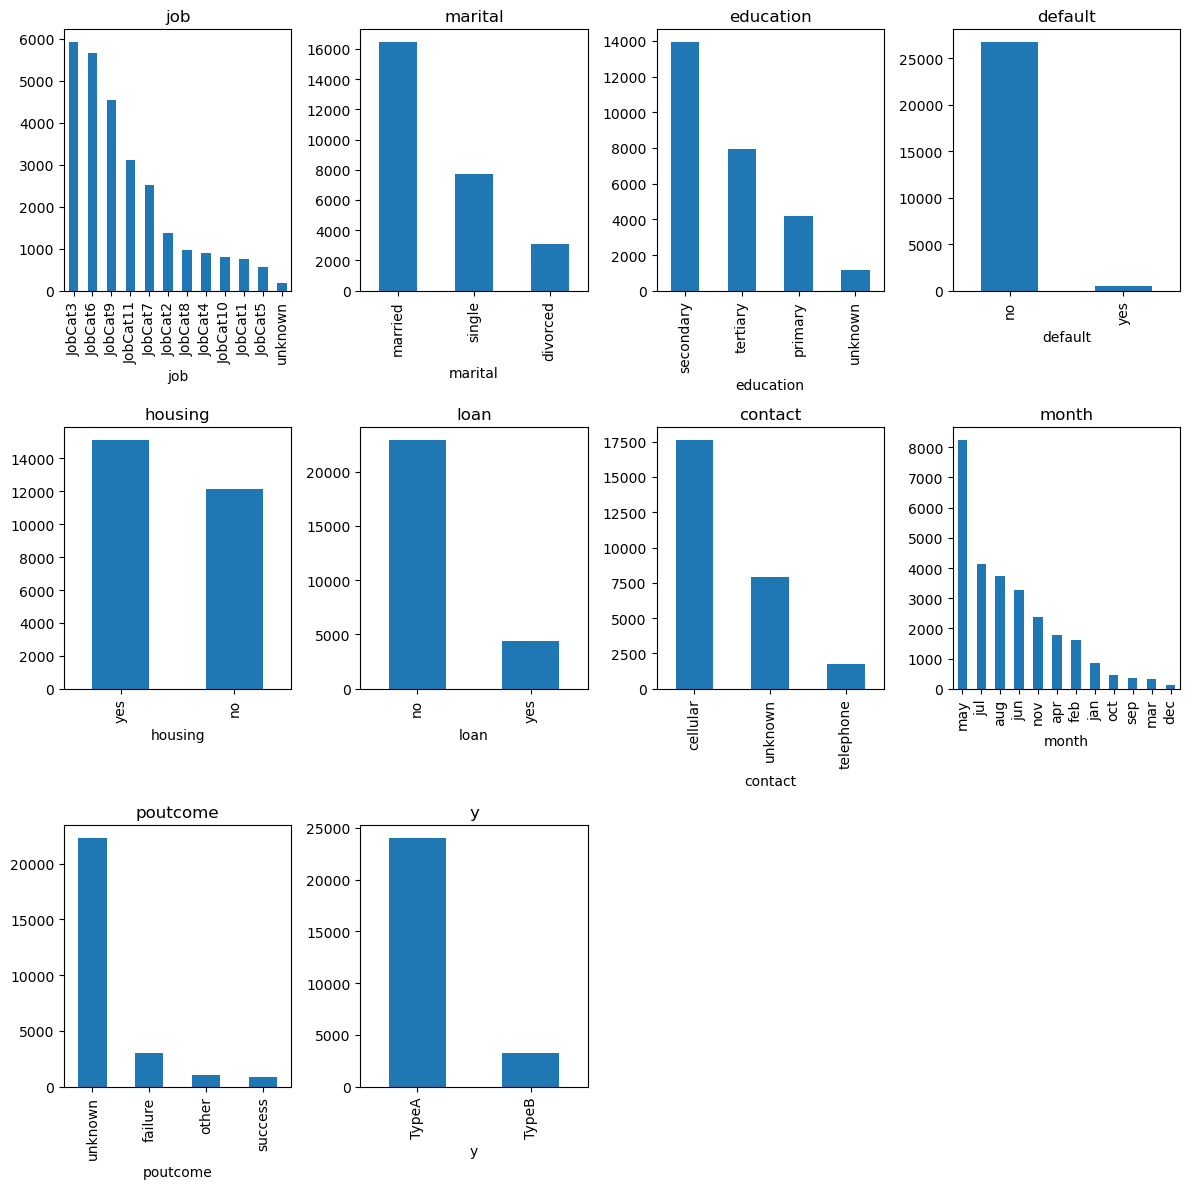

In [9]:
# Categorical Plots
# List of categorical columns
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

n_cols = 4  # define the number of columns

# now we check if the number of columns of that type is divisible by the number of columns we defined
if len(categorical_columns) % n_cols == 0:  # if it is divisible (no remainder)
    n_rows = int(len(categorical_columns) / n_cols)
else:  # if it is not divisible (remainder)
    n_rows = int(len(categorical_columns) / n_cols) + 1

# define the figure and its subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 12))  # increased figsize for better view

cur_col = 0  # here we'll store the current column of the plot we are at
cur_row = 0  # here we'll store the current row of the plot we are at

# Iterate over the column's names
for column_name in categorical_columns:
    # Plot the value counts for each categorical column
    df_ts[column_name].value_counts().plot(kind='bar', ax=axes[cur_row, cur_col], title=column_name)
    
    # Move to the next column
    cur_col += 1
    
    # After, we must check we are still within the boundaries
    if cur_col == n_cols:  # if we are beyond the boundary:
        cur_row += 1  # move to the next row (i.e., increment the row count)
        cur_col = 0  # reset the count of columns (i.e., position at the first column)

# Remove unused axes (we are working with categorical columns here, so check for the number of categorical axes)
for ax in axes.flat[len(categorical_columns):]:
    ax.remove()

# Clean layout for a better look
plt.tight_layout()

# Display the plots
plt.show()

2.4 Viauslaise Numerical features

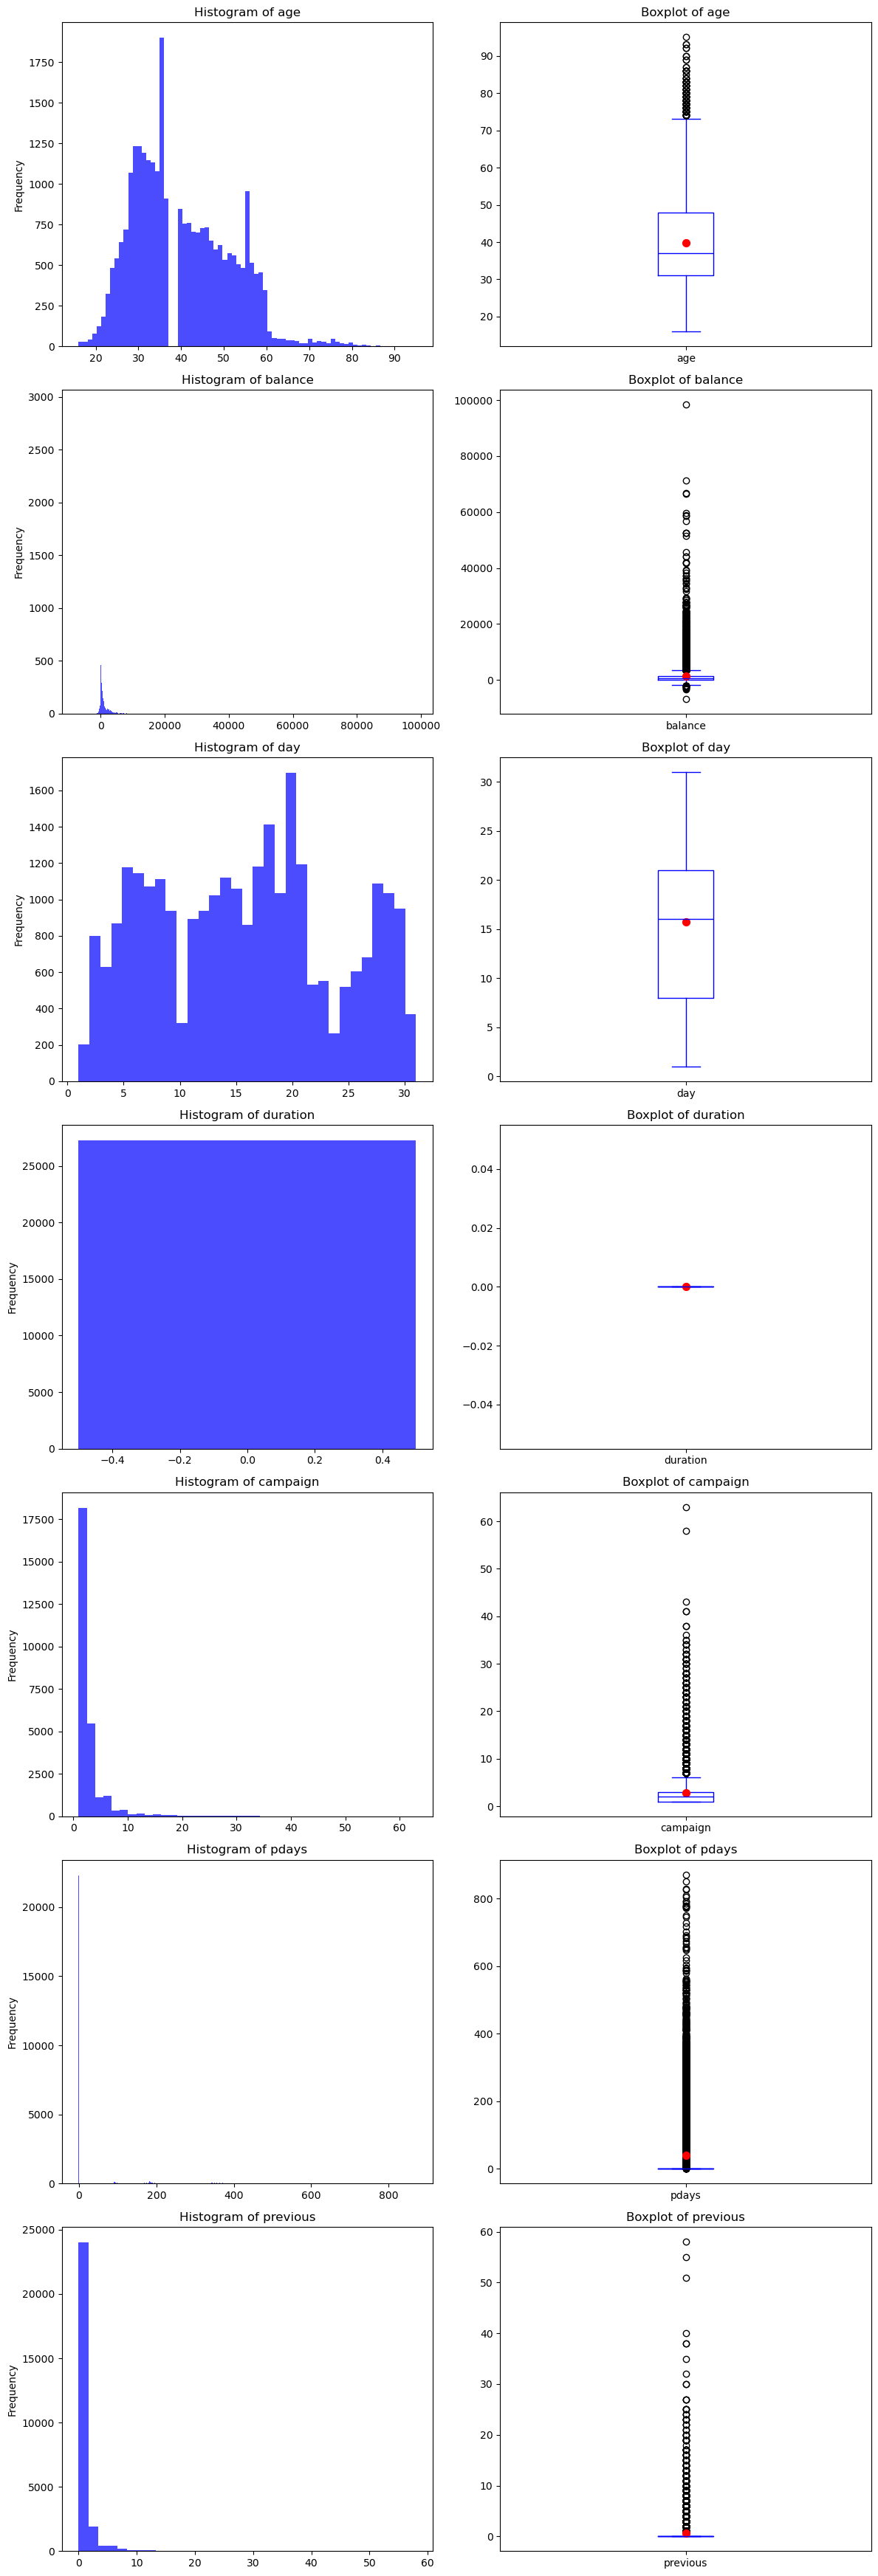

In [10]:
# Select numeric columns
## include=['number'] tells pandas to filter columns that have a numeric data type, i.e int64 or float64 as per above.
numeric_columns = df_ts.select_dtypes(include=['number']).columns

# create subplots: (# of rows,(number(len) of numeric columns) *2 columns one for histogram and one for boxplot. 
## Figsize here is doing 12 inches width and height is 5, but making it longer for the amount of numerical data hence len(numeric_columns)
fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(12, 5 * len(numeric_columns)))

## enumerate() adds an index (starting from 0 by default) to an iterable.
### Each iteration assigns:
#### i The index (0, 1, 2, 3 etc.)
#### col: The column name 

for i, col in enumerate(numeric_columns):
    # Calculate mean for each varaible for use in the scatterplot below 
    
    mean_value = df_ts[col].mean()

    ### Note here for the hsitograms we are using the number of bins assocaited with nunque of the varaibles. 
    num_bins = df_ts[col].nunique()
    
    # Histogram: 50 bins, 70% transparcency, blue, put it in row(i) starting from 0 and col 0 so first column.
    df_ts[col].plot(kind='hist', bins=num_bins, alpha=0.7, color='b', ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}')

    # Boxplot (transposing it on its side and adding the mean per variable ina  scatter plot)
    df_ts[col].plot(kind='box', color='b', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    # Trying to get the boxplot to stay within th eimage, struggling with this part. 
    #axes[i, 1].set_xlim(bankdf[col].min() - 5, bankdf[col].max() + 5)
    # Adding scatterplit just ot have mean as a dot
    ## Z order is to overlay the mean on the graph kind of like ggplot2
    axes[i, 1].scatter(1,mean_value, color='red', s=50, zorder = 2) 

# Adjust layout
plt.tight_layout()
plt.show()

2.4 View Traingin data structure, cleanliness and statistics.

In [11]:
# lok at the data dtypes
print(df_ts.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27272 entries, 0 to 27271
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        27272 non-null  int64 
 1   job        27272 non-null  object
 2   marital    27272 non-null  object
 3   education  27272 non-null  object
 4   default    27272 non-null  object
 5   balance    27272 non-null  int64 
 6   housing    27272 non-null  object
 7   loan       27272 non-null  object
 8   contact    27272 non-null  object
 9   day        27272 non-null  int64 
 10  month      27272 non-null  object
 11  duration   27272 non-null  int64 
 12  campaign   27272 non-null  int64 
 13  pdays      27272 non-null  int64 
 14  previous   27272 non-null  int64 
 15  poutcome   27272 non-null  object
 16  y          27272 non-null  object
dtypes: int64(7), object(10)
memory usage: 3.5+ MB
None


In [12]:
# view statistics for numerical data
print(df_ts.describe())

                age       balance           day  duration      campaign  \
count  27272.000000  27272.000000  27272.000000   27272.0  27272.000000   
mean      39.880463   1361.079459     15.769287       0.0      2.739623   
std       11.426248   3015.207142      8.300983       0.0      3.011097   
min       16.000000  -6847.000000      1.000000       0.0      1.000000   
25%       31.000000     73.000000      8.000000       0.0      1.000000   
50%       37.000000    447.000000     16.000000       0.0      2.000000   
75%       48.000000   1423.000000     21.000000       0.0      3.000000   
max       95.000000  98417.000000     31.000000       0.0     63.000000   

              pdays      previous  
count  27272.000000  27272.000000  
mean      40.074105      0.578872  
std      100.200984      1.942882  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.000000  
max      871.000000     58.000000  


In [17]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# df_ts=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , df_ts.shape[0])
print ("Columns  : " , df_ts.shape[1])
print('------')
print ("\nFeatures : \n" , df_ts.columns.tolist())
print('------')
print ("\nMissing values :  ", df_ts.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", df_ts.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(df_ts.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", df_ts.nunique())
print('------')
print('\n null values = ', df_ts.isnull().values.any())
print('------')
df_ts_missing = (df_ts=='?').sum()
print('\"  ?   \" values present =  \n',df_ts_missing)
print('------')
df_ts_unknown = (df_ts=='unknown').sum()
print('\"   unknown   \" values present =  \n',df_ts_unknown)
print('------')
df_ts_na = df_ts.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', df_ts_na)
print('------')
df_ts_none = df_ts.isin(['None', 'none']).sum()
print('    none    values present = \n', df_ts_none)
print('------')
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
rogue_ascii_df = df_ts.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", rogue_ascii_df)

Rows     :  27272
Columns  :  17
------

Features : 
 ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
------

Missing values :   0
------

Missing values per column:   age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
------

num of dups in df   =   7
------

Unique values :  
 age            75
job            12
marital         3
education       4
default         2
balance      5939
housing         2
loan            2
contact         3
day            31
month          12
duration        1
campaign       41
pdays         499
previous       35
poutcome        4
y               2
dtype: int64
------

 null values =  False
------
"  ?   " values present = 

In [ ]:
# Age category exploration - print number of uses in outlier categories
print(f"Number of users who were < 18 -  {len(df_ts[df_ts['age'] < 18])}")
print(f"Number of users who were > 75 -  {len(df_ts[df_ts['age'] > 65])}")

# number who actually took out a term deposit in thse age bracket 

# only two unique valeus for term deposit 'yes' or 'no' - we'll filter on those per age group
print(f"Number of users who were < 18 and took out a Loan - {len(df_ts[(df_ts['age'] < 18) & (df_ts['loan'] == 'yes')])}")

print(f"Number of users who were > 72 and took out a Loan - {len(df_ts[(df_ts['age'] > 72 ) & (df_ts['loan'] == 'yes')])}")

Number of users who were < 18 -  30
Number of users who were > 75 -  440


KeyError: 'term deposit'

In [18]:
# JOb category exploration - get job unique values count - we have 178 unknown - this could be unemployed or just not known... 
# we have no insight into categories within our dataset, so will leave 

print(df_ts['job'].value_counts())

job
JobCat3     5927
JobCat6     5664
JobCat9     4539
JobCat11    3102
JobCat7     2510
JobCat2     1370
JobCat8      965
JobCat4      900
JobCat10     800
JobCat1      754
JobCat5      563
unknown      178
Name: count, dtype: int64


In [19]:
# Campaign contact exploratoin - number of times a user was conacted against whetehr or not they took up a loan
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

# updated bins — single contact gets its own bin
campaign_bins   = [0, 1, 5, 10, 20, 30, 40, 50, 64]
campaign_labels = ['1', '2-5', '6-10', '11-20', '21-30', '31-40', '41-50', '51-63']

df_ts['campaign_bin'] = pd.cut(df_ts['campaign'], 
                                bins=campaign_bins, 
                                labels=campaign_labels, 
                                right=True)

# summary table
campaign_summary = df_ts.groupby('campaign_bin', observed=True).agg(
    total           = ('is_typeB', 'count'),
    converted       = ('is_typeB', 'sum'),
    conversion_rate = ('is_typeB', 'mean')
).reset_index()

campaign_summary['not_converted']   = campaign_summary['total'] - campaign_summary['converted']
campaign_summary['conversion_rate'] = (campaign_summary['conversion_rate'] * 100).round(2)

print(campaign_summary[['campaign_bin','total','converted',
                         'not_converted','conversion_rate']].to_string(index=False))


campaign_bin  total  converted  not_converted  conversion_rate
           1  10641       1569           9072            14.74
         2-5  14067       1526          12541            10.85
        6-10   1864        117           1747             6.28
       11-20    565         27            538             4.78
       21-30    107          2            105             1.87
       31-40     23          1             22             4.35
       41-50      3          0              3             0.00
       51-63      2          0              2             0.00


In [20]:
# check how many type b values there are for each education type
# this is to help us determine fi we need to incldue ordinal nature of education and where unknown might sit

# TypeB conversion count and rate by education level
edu_summary = df_ts.groupby('education').agg(
    total           = ('y', 'count'),
    typeB_count     = ('y', lambda x: (x == 'TypeB').sum()),
    typeA_count     = ('y', lambda x: (x == 'TypeA').sum()),
    conversion_rate = ('y', lambda x: round((x == 'TypeB').mean() * 100, 2))
).reset_index()

# sort by conversion rate descending
edu_summary = edu_summary.sort_values('conversion_rate', ascending=False)

print(edu_summary.to_string(index=False))

education  total  typeB_count  typeA_count  conversion_rate
 tertiary   7947         1216         6731            15.30
  unknown   1172          169         1003            14.42
secondary  13949         1494        12455            10.71
  primary   4204          363         3841             8.63


In [21]:
# balance and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all balances
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

balance_bins   = [-7000, 0, 10000, 20000, 30000, 40000, 50000, 60000, 100000]
balance_labels = ['<0', '0-10k', '10k-20k', '20k-30k', 
                  '30k-40k', '40k-50k', '50k-60k', '60k+']

df_ts['balance_bin'] = pd.cut(df_ts['balance'], 
                               bins=balance_bins, 
                               labels=balance_labels, 
                               right=True)

total_rows = len(df_ts)

balance_summary = df_ts.groupby('balance_bin', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
).reset_index()

# percentage of total in bucket that are typeB
balance_summary['typeB_pct_of_bucket'] = (balance_summary['typeB_count'] / 
                                           balance_summary['total'] * 100).round(2)

# percentage of whole dataset
balance_summary['bucket_pct_of_all']   = (balance_summary['total'] / 
                                           total_rows * 100).round(2)


# typeB_pct_of_bucket >  the percentage type b in the total in that blance range? i.e. for the 0-10k range 22367 is the total number of cstomers ni that balance  and typeB_pct_of_bucket is the percentage of that bucket that are typeB?
print(balance_summary[['balance_bin', 
                        'total',
                        'bucket_pct_of_all',
                        'typeA_count', 
                        'typeB_count',
                        'typeB_pct_of_bucket']].to_string(index=False))

# clean up
df_ts = df_ts.drop(columns=['balance_bin'])

balance_bin  total  bucket_pct_of_all  typeA_count  typeB_count  typeB_pct_of_bucket
         <0   4412              16.18         4109          303                 6.87
      0-10k  22367              82.01        19512         2855                12.76
    10k-20k    386               1.42          320           66                17.10
    20k-30k     74               0.27           61           13                17.57
    30k-40k     15               0.06           12            3                20.00
    40k-50k      6               0.02            6            0                 0.00
    50k-60k      8               0.03            6            2                25.00
       60k+      4               0.01            4            0                 0.00


In [22]:
# loanand number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

total_rows = len(df_ts)

loan_summary = df_ts.groupby('loan', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
).reset_index()

loan_summary['bucket_pct_of_all']    = (loan_summary['total'] / 
                                         total_rows * 100).round(2)
loan_summary['typeB_pct_of_bucket']  = (loan_summary['typeB_count'] / 
                                         loan_summary['total'] * 100).round(2)
loan_summary['typeA_pct_of_bucket']  = (loan_summary['typeA_count'] / 
                                         loan_summary['total'] * 100).round(2)

print(loan_summary[['loan', 'total', 'bucket_pct_of_all',
                     'typeA_count', 'typeB_count',
                     'typeA_pct_of_bucket',
                     'typeB_pct_of_bucket']].to_string(index=False))

loan  total  bucket_pct_of_all  typeA_count  typeB_count  typeA_pct_of_bucket  typeB_pct_of_bucket
  no  22921              84.05        19974         2947                87.14                12.86
 yes   4351              15.95         4056          295                93.22                 6.78


In [ ]:
# loanand number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

total_rows = len(df_ts)

contact_summary = df_ts.groupby('contact', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
).reset_index()

contact_summary['bucket_pct_of_all']   = (contact_summary['total'] / 
                                           total_rows * 100).round(2)
contact_summary['typeB_pct_of_bucket'] = (contact_summary['typeB_count'] / 
                                           contact_summary['total'] * 100).round(2)
contact_summary['typeA_pct_of_bucket'] = (contact_summary['typeA_count'] / 
                                           contact_summary['total'] * 100).round(2)

print(contact_summary[['contact', 'total', 'bucket_pct_of_all',
                        'typeA_count', 'typeB_count',
                        'typeA_pct_of_bucket',
                        'typeB_pct_of_bucket']].to_string(index=False))

  contact  total  bucket_pct_of_all  typeA_count  typeB_count  typeA_pct_of_bucket  typeB_pct_of_bucket
 cellular  17633              64.66        14942         2691                84.74                15.26
telephone   1742               6.39         1515          227                86.97                13.03
  unknown   7897              28.96         7573          324                95.90                 4.10


In [23]:
# balance and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all balances
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

total_rows = len(df_ts)

loan_summary = df_ts.groupby('loan', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
).reset_index()

loan_summary['bucket_pct_of_all']    = (loan_summary['total'] / 
                                         total_rows * 100).round(2)
loan_summary['typeB_pct_of_bucket']  = (loan_summary['typeB_count'] / 
                                         loan_summary['total'] * 100).round(2)
loan_summary['typeA_pct_of_bucket']  = (loan_summary['typeA_count'] / 
                                         loan_summary['total'] * 100).round(2)

print(loan_summary[['loan', 'total', 'bucket_pct_of_all',
                     'typeA_count', 'typeB_count',
                     'typeA_pct_of_bucket',
                     'typeB_pct_of_bucket']].to_string(index=False))

loan  total  bucket_pct_of_all  typeA_count  typeB_count  typeA_pct_of_bucket  typeB_pct_of_bucket
  no  22921              84.05        19974         2947                87.14                12.86
 yes   4351              15.95         4056          295                93.22                 6.78


In [24]:
# worth checking if day has any signal for TypeB
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)
print(df_ts.groupby('day')['is_typeB'].agg(['mean','count'])
      .rename(columns={'mean':'typeB_rate'})
      .round(3))

     typeB_rate  count
day                   
1         0.279    204
2         0.141    801
3         0.164    628
4         0.160    869
5         0.104   1179
6         0.098   1144
7         0.100   1072
8         0.107   1110
9         0.117    939
10        0.221    321
11        0.142    892
12        0.148    939
13        0.166   1022
14        0.110   1119
15        0.142   1060
16        0.151    859
17        0.093   1180
18        0.101   1413
19        0.068   1035
20        0.072   1697
21        0.091   1194
22        0.181    531
23        0.128    553
24        0.114    263
25        0.155    521
26        0.125    606
27        0.136    682
28        0.074   1087
29        0.073   1033
30        0.177    949
31        0.068    370


In [25]:
# loan and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

total_rows = len(df_ts)

month_summary = df_ts.groupby('month', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
    typeB_rate  = ('is_typeB', 'mean')
).reset_index()

month_summary['typeB_rate']   = (month_summary['typeB_rate'] * 100).round(2)
month_summary['pct_of_total'] = (month_summary['total'] / 
                                  total_rows * 100).round(2)

# sort by conversion rate descending
month_summary = month_summary.sort_values('typeB_rate', ascending=False)

print(month_summary[['month', 'total', 'pct_of_total',
                      'typeA_count', 'typeB_count',
                      'typeB_rate']].to_string(index=False))

month  total  pct_of_total  typeA_count  typeB_count  typeB_rate
  mar    308          1.13          143          165       53.57
  sep    371          1.36          197          174       46.90
  dec    124          0.45           68           56       45.16
  oct    451          1.65          250          201       44.57
  apr   1795          6.58         1429          366       20.39
  feb   1610          5.90         1335          275       17.08
  aug   3739         13.71         3322          417       11.15
  jan    841          3.08          756           85       10.11
  jun   3283         12.04         2951          332       10.11
  nov   2384          8.74         2149          235        9.86
  jul   4117         15.10         3754          363        8.82
  may   8249         30.25         7676          573        6.95


In [26]:
# poutcome and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
# TypeB conversion by poutcome category
# TypeB conversion by poutcome category
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

total_rows = len(df_ts)

poutcome_summary = df_ts.groupby('poutcome', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
    typeB_rate  = ('is_typeB', 'mean')
).reset_index()

poutcome_summary['pct_of_total'] = (poutcome_summary['total'] / 
                                     total_rows * 100).round(2)

poutcome_summary['typeB_rate']   = (poutcome_summary['typeB_rate'] * 100).round(2)

poutcome_summary['typeA_pct']    = (poutcome_summary['typeA_count'] / 
                                     poutcome_summary['total'] * 100).round(2)

poutcome_summary['typeB_pct']    = (poutcome_summary['typeB_count'] / 
                                     poutcome_summary['total'] * 100).round(2)

# sort by conversion rate descending
poutcome_summary = poutcome_summary.sort_values('typeB_rate', ascending=False)

print(poutcome_summary[['poutcome', 'total', 'pct_of_total',
                         'typeA_count', 'typeA_pct',
                         'typeB_count', 'typeB_pct']].to_string(index=False))

poutcome  total  pct_of_total  typeA_count  typeA_pct  typeB_count  typeB_pct
 success    906          3.32          301      33.22          605      66.78
   other   1052          3.86          871      82.79          181      17.21
 failure   2998         10.99         2621      87.42          377      12.58
 unknown  22316         81.83        20237      90.68         2079       9.32


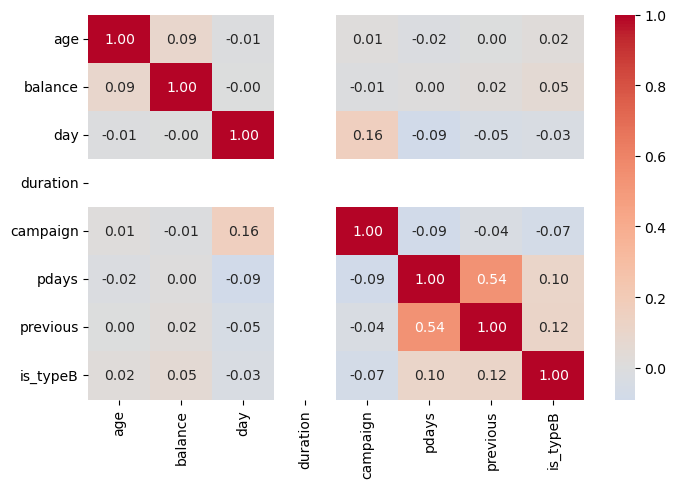

In [27]:
# Checking the correlations in numerical data - colinearity check
## Noting how the sign changed between pdays and previous now. 

# making correlation matrix
# corr_matrix=df_ts[numeric_columns].corr()
# corr_matrix

NUM_COLS = df_ts.select_dtypes(include=['number']).columns.tolist()

corr_matrix = df_ts[NUM_COLS].corr()

# Seaborn graph of correlation matrix

fig , ax = plt.subplots(figsize = (8,5))
sns.heatmap(corr_matrix, annot = True, fmt='.2f', cmap='coolwarm', center=0,  ax=ax)

plt.tight_layout
plt.show()

2.4 Feature Analysis and next steps outline


**NOTE:** This daatset is based of the [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) data. We based our details and understanding of the individual features for this assignment as well as the details available for the **UCI Bank Marketing** data set.

we will look at them int he context of numerical and categorical features.

- **Numerical** 
    - 'age'
        - dtype = int64
        - no missing, corrupted of NaN values
        - min age = 16, max age = 95, 
        - Kurtosis ~ -0.05 / skewness ~ 0.59 / std dev ~ 11 / mean ~ 39 / median ~ 37
        - slight right skewness, with long tail to aged 95, not imbalanced and no extreme outliers.
        - Peak values land between 30 to 35 years old with IQR = 17, middle 50% of data between 31 and 48
        - no one < 18 took out a term deposit, but there may be legal issues anyway as to whether they are valid audience, so will remove them.
        - age > 65 - although retired, the data still has term deposits issued up to 71 years. May be predictive value in this so will leave > 65 ages present in the data. Even up to 95, these are real ages and real data, we will see how that affects the results
        - Next Step >>
            - remove ages < 18
            - assume normally distributed
            - Could apply Standard scalar (z score normalization - mean and std dev), but will apply RobustScalar (median + IQR) to keep the feature aligned with the use of RobustScalar on other features. 
            - dtype remains as int64

    - 'balance'
        - dtype = int64 
        - This is the balance in peoples bank accounts
        - no missing, corrupted of NaN values
        - min = -6847, max = 98417, with 2115 '0' values  
        - Kurtosis ~ 126 / skewness ~ 8 / std dev ~ 3015 / mean ~ 1361 / median ~ 447
        - Kurtosis is leptokutic and highly right skewed... big peak near zero with long tail.. (normal distribution being = 3)
        - negative value is money owed.. big spread with extreme outliers
        - IQR = 1350, => middle 50% is tightly packed
        - Can see most sit int he 0-10K range, But the highest number of Type B outcomes are iny eh higher balance ranges i.e. 30-40K = 20% and 50-60K = 25%. While they have less customers in those brackets more of those customers have a type B outcome. 
        - From  business poitn of view thet need to target more customers with higher bank balances to have greatest chance of gettign type B outcomes.
        - log or robust scalar? - do nothing? if tre based model might be fine...
        - Next Steps
            - would benefit from being transformed 
            - Any transformation will also have to accommodate negative and zero values... as they are real data, real bank balances.
            - transform >> we could shift everything by adding 6848 to each value(addresses minus sign and zeros) + apply log1p + apply robust scalar
            - a simpler option may be to just handle outliers using Robust scalar (mean and IQR)
            - Scale using Robust Scalar.. it handles negative values and also zero values...

    - 'day'
        - dtype = 'int64'
        - days of the month 
        - no missing, NaN, 'unknown', negative values, zeros, or corrupt data
        - min value 1 - max value  31
        - not a real numeric value, more categorical in that it represents a day of a month.
        - there are peaks and troughs which may correspond to weekends and busy days of the week, is periodic in behaviour.
        - no unusual imbalance to take account of
        - Kurtosis = ~ -1  (flat enough data no major peaks)/ skewwness = 0.096 (no skewness)
        - we could calculate the actual day of the week, as people could be more receptive on particular days of the week, however we do not have the year value to calculate it reliably, only date and month. Due to this uncertainty we will not feature engineer or add a time series component.
        - Next Steps
            - could one-hot encode but that would be adding dimensions with questionable return
            - will leave as is as int64 
            - will not scale as more categorical than numerical

    - 'duration'
        - dytype  = int64
        - how long a call lasted
        - 27272 values = '0' - no other values present, no variation or information in the data.
        - Also, we don't know before we make a call, how long that call will last, so the useful ness fo this feature is questionable.
        - Next Steps
            - we will remove the feature

    - 'campaign'
        - dtype  = 'int64'
        - number of times a user was contacted during this single campaign for which we have data.
        - no missing, NAN, zeros, negative numbers or corrupt data
        - min = 1  / max = 63 with 41 unique values. All whole numbers, no floats.
        - Kurtosis ~ 37 / skewness ~ 4 / std dev ~ 3 / mean ~ 2.7 / median ~ 2
        - 10,641 customers received only 1 call.
        - some customers were contacted up to 63 times in this campaign
        - not normally distributed - IQR - 1 to 3 but have low number outliers then out to '63'
        - sharp peak with kurtosis = 37.3 
        - long right tail with skewness of ~ 4
        - 1 contact  = ~ 14% outcome of TypeB - highest rate
        - 2 - 5 contacts = ~ 10% outcome of TypeB
        - nobody contacted > 40 times took out a term deposit and conversion rate gets less the more a user is contacted.... Ther is an inverse relationship between the number of times a customer is contacted and the number of customers taking out a term deposit. 
        - From a business perspective there is too much time in call centre ringing customers who will not buy. Worth reviewing the process based off this. If do not convert after a low, set number of contacts, do not ring them again.
        - Next Steps
            - leave dtype as is = int64
            - convert to log1p to address skewness and distribution
            - followed by Scaling using RobustScalar (media / IQR) to handle the outliers

    - 'pdays'
        - dtype = 'int64' 
        - number of days since client was last contacted in an earlier campaign (previous days)
        - No missing, corrupted or NaN values
        - 499 unique values
        - (22313 ) or 81% are '-1', other values are spread across 498 different values, no one value dominates.
        - '-1' = never contacted before, so it has no numerical relationship to the other values in the feature. rather it is a flag, which means they haven't been contacted before and as such as new customers. 
        - IQR = 0 i.e. Q1, Q2 and Q3 are all -1. i.e. the top 75% of values are all '-1' 
        - The other values being a spread of small number of occurences of a large spread of values the max of which is '871'. These are old or existing customers, some of which have not been contacted in 1, 2 or more years.
        - Kurtosis ~ 7 (a sharp peak)/ skewness ~ 2.6 (right skewed)/ std dev ~ 100 / mean ~ 40 / median = -1
        - heavily right skewed, with a long tail, large spread of data
        - Not really a continuous set of numerical variables, its more of a categorical features, mixture of two sets of information. it is a flag as to whether or not previously contacted and then some variables representig duration since last contacted.  There are two different data dtypes in the feature.
        - Next Steps
            - Will split into new columns, 
                - column 1 (new) - 'contacted_previously' binary cetegorical  > 
                    - '1' = was contacted_previously 
                    - '0' = not contacted_previously
                    - dtype = int64 > will be binary numeric , but is categorical.
                - column 2 (existing column - Retain this column)
                    - Retain numbers of days since last contacted in this column as they are
                    - change the '-1' value to '0' to indicate customer has not been contacted before.
                    - dtype = 'int64' - leave as is i.e.'int64'
                    - Followed by applying 'log1p' natural log transformation to reduce the skewness and reshape the distribution, this will help logistical regression and naive bayes models with data shape and scaling
                    - followed by scaling using RobustScalar as we will have 22,313 '0' values 

    - 'previous'
        - dtype  = 'int64'
        - how many times a customer ws previously contacted.
        - no missing, negative, NaN or corrupt values
        - 35 distinct/unique values with, with a min = '0' and max = '58'
        - 81.8% (22313) are '0' which means never contacted before. This ties in with previous feature pdays which had 81.8% as '-1', meaning never contacted before, again as previously indicating new customers.
        - Kurtosis ~ 124 (a sharp peak)/ skewness ~ 8 (heavily right skewed)/ std dev ~ 1.9 / mean ~ 0.57 / median = 0
        - IQR = 0 => Q1, Q2 and Q3 are the same i.e. they are all '0'. i.e. at least 75% of values are all '0' and as can be designated as new customers.
        - Next Steps
            - dtype = 'int64' - leave as is i.e.'int64'
            - Scale by applying 'log1p' natural log transformation to reduce the skewness and reshape the distribution
            - followed by scaling using RobustScalar to address skewness


    




- **Categorical**
    - 'job'
        - dtype = 'object' 
        - customer job type
        - 12 unique job types and 178 'unknown' values = 13 categories in total
        - Jobs 3, 16 and 19 dominate - JobCat3=5927(21.7%) / JobCat6=5664(20.8%) / JobCat9=4539(16.6%)
        - no missing, NAN values or corrupted data
        - we have no insight into categories within our dataset, the dataset has been annonymised, if unemployed or not, or special category high paying jobs not available, as such will leave as is, including 'unknown' job category
        - Nest Steps
            - covert to binary categorical for each of the 12 categories - use one-hot encoding
            - Will increase dimensionality but no other option to convert to numerical without adding dimensions and there is predictive value in the feature
            - dtype changes to 'int64'

    - 'marital'
        - dtype = 'object' 
        - marital status of customer
        - no missing, NaN, 'unknown' or corrupt data
        - 3 unique values, - 'married'=16462(~60%) / 'single'=7728(~28%) / 'divorced'= 3082(~11%) = total 27272.
        - Is imbalanced but may reflect sample population from banking perspective i.e. middle aged married have most dealign with banks, mortgages etc
        - Next Steps
            - covert to binary categorical for each category - use one-hot encoding
            - dtype will be converted to binary numeric (but is effectively still a categorical and not numeric continuous)


    - 'education'
        - dtype = 'object'
        - education level for customer
        - no missing, NaN, 'unknown' or corrupt data
        - 4 unique values  - secondary=13,949(~51%) / tertiary=7,947 (~29%) / primary=4204 (~15%) / unknown=1172 (~ 4%)
        - no insight into "unknown" value - will keep this data as is, could be useful predictor
        - There is an ordinal element to the data with secondary being higher than primary and tertiary being higher than secondary, however where does unknown fit into hierarchy.
        - 'unknown' has the second highest typeb values, at ~ 11%, after tertiary, hence is important predictor.
        - Next Steps
            - will use one-hot encoding for all 4 categories
            - increases dimensions, however need to retain 'unknown' and doesn't quite fit into ordinal data structure easily.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous)

    - 'default'
        - dtype = 'object'
        - whether or not someone has previously defaulted on a loan.
        - no missing, NaN, 'unknown' or corrupt data
        - two categories - no=26788(98.2%) / yes=484(1.8%)
        - very imbalanced -
        - Real data so will keep even though heavily imbalanced
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = int64 (although numeric is effectively binary categorical)
    
    - 'housing'
        - dtype = 'object'
        - Whether or not they own their own home
        - no missing, NaN, 'unknown' or corrupt data
        - reasonably balanced
        - 'yes' = 15131  / 'no'	= 12141 
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = int64 (although numeric is effectively binary categorical)
    
    - 'loan'
        - dtype = 'object'
        - Whether or not they have an existing loan.
        - no missing, NaN, 'unknown' or corrupt data
        - is imbalanced
        - 'no'= 22921(84.0%) / 'yes'= 4351(16.0%)
        - 12% who have no loan are type B, whereas 6% who have loans are type B. Customers who do not have a loan are two times more ilkely to take out a term deposit and become type B customers. This makes sense as they have more disposable income.
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = int64 (although numeric is effectively binary categorical)    

    - 'contact'
        - dtype = 'object'
        - How customers were contacted during the bank marketing campaign
        - no missing, NaN, 'unknown' or corrupt data
        - 3 values - cellular=17633 (64.7%)  /  unknown=7897(29.0%) /  telephone=1742(6.4%)
        - Imbalanced but are real values as most people do not have a land line, rather a mobile phone, the 'unknown' could be missing values, not recorded, possibly email or cold calling.
        - ~ 15% of cellular are type B, followed by ~11% for telephone and ~4% for unknown. With Cellular having the strongest performance.
        - could be related to age or a demographic younger people having mobile phones, and older people not adopting new technologies, as well as people being more open to engaging in different means of communication
        - Next Steps
            - will use one-hot encoding for all 3 categories
            - increases dimensions, however need to retain 'unknown' and doesn't quite fit into ordinal data structure easily.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous))
    
    - 'month'
        - dtype = 'object'
        - month of when contact was .
        - no missing, NaN, 'unknown' or corrupt data
        - big peak in May=8249(~30%), and then also in June, July=(4117(~ 15%)) / Aug=3729(~ 13%) and June=3283(12%)
        - big drop off in Sept=371(1.4%), Oct=451(1.7%) , Mar=308() and Dec 124()
        - Somewhat counter intuitive outcome from number of calls made
            - May = 8249 call made  > 573 (6.9%) resulted in TypeB outcome
            - Mar = 308 calls made > 165 (53.6%) resulted in TypeB outcome
            - explanations could be from a variety of factors, perhaps the customer type that ws rung, seasonal change of focus in customer, we do not have sufficient information to determine why this outcome is present. Regardless of cause month in this dataset adds a predictive value outside of the number of calls made.
        - There is some seasonality which may be a result of campaign duration
        - Next Steps
            - one-hot encoding for the months
            - will increase dimensionality but is a relevant feature with predictive value, as such the trade off should be worth this increase in dimensionality.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous))

    - 'poutcome'
        - dtype = 'object'
        - previous outcome of whether a customer took out a term deposit or not, so provides past customer outcome.
        - no missing, null or corrupt values etc
        - Imbalanced data - unknown=22316(81.8%)/ failure=2998(11.0%)/other=1052(3.9%)/success=906(3.3%)
        - 'unknown' is aligned with pdays value '-1' and previous value '0' i.e. in that it is not known previous outcome, there was no contact previously.
        - TYpeB outcome for customers who had success in previous campaign = 66% / other = 17.21% / failure = 12.58% / unknown  = 9.32%. 
        - 'success' is a very strong predictor in the dataset
        - 'Unknown' contains > 81% of the data, but has the lowest typeB outcome rate.
        - Next Step
            - one-hot encoding, binary columns.
            - drop_first=true for linear models to avoid multi colinearity - i.e. this will drop the first category to act as a reference grou, which is 'poutcome_unknown', no negative impact on RF, GB, KNN and NB
            - dtype =int64 - change dytpe after one-hot encoding
    
    - 'y'
        - dtype = 'object'
        - Our target variable  
        - TypeA = no sale / TypeB  = sale
        - 2 unique values -  TypeA=24030(88.1%) /  TypeB=3242(11.9%)
        - Most customers did not take out a term deposit, 
        - Is imbalanced
        - We need binary predictor for who will take out a term deposit i.e. want to predict TypeB customers, who will take out a term deposit. Will need to predict a minority class
        - if just predicted typeA for every customer we would get 88% accuracy, but that would not be useful to us, we need to predict the minority class of 11% type Bs.
        - Next Steps
            - will encode - map existing values as below, as models will work in numerical values, distances and probabilities and threshold values.
                - TypeA = 0
                - TypeB = 1
            - will use stratified split in train test split
            - will not encode query dataset target column
            - will using evaluation metrics such as F1 score, recall, precision, roc-auc 
            - wil consider using class_weight= 'balanced' / RandomOverSampler / SMOTE to improve minority class prediction
            - will change to 'int64' but remain a binary categorical feature 

NOTE: all feature scaling and transformations will be applied to both training (*df_ts*), and query (*df_qry*) datasets, **except** for target variable 'y'. We will not touch target variable 'y' on the query set.

Alos, we note that the correlation matrix shows some level fo colinearity between 'pdays' and 'previous', with a value of 0.54. While this is real it is not of a level as to warrant deletion of one of the elements at this stage, and as sch we will leave both for now. We will revisit if we have to.

## Step 3: Next Steps Outline - Summary of Feature Actions


- 'duration': delete feature
- 'age': remove ages < 18 yrs + apply RobustScalar + dtype remains as 'int64'
- 'balance': apply RobustScalar + dtype remains as 'int64'
- 'day': apply RobustScalar + dtype remains as 'int64'
- 'campaign': log transform using 'log1p' + apply RobustScalar + dtype remains as 'int64'
- 'pdays': 
    - create mew feature 'contacted_previously' 
        - dtype = 'int64'
        - 1 = contacted previously 
        - 0 = not contacted previously
    - existing column
        - change '-1' value to zero + log transform using 'log1p'  + apply RobustScalar
        - name is same + dtype remains 'int64'
- 'previous': log transform using 'log1p' + apply RobustScalar + dtype remains as 'int64'
- 'job': one-hot encoding for all 13 categories + dtype changes to 'int64'     
- 'marital': one-hot encoding for 3 values 'married', 'single' and 'divorced' + dtype changes to 'int64'        
- 'education': one-hot encoding for 4 values 'unknown', 'primary', 'secondary' and 'tertiary' + dtype changes to 'int64'       
- 'default': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int64'         
- 'housing': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int64'      
- 'loan': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int64'  
- 'contact': one-hot encoding for 3 values 'cellular', 'unknown' and 'telephone' + dtype changes to 'int64'  
- 'month':  one-hot encoding for all 12 months + dtype changes to 'int64'                    
- 'poutcome': one-hot encoding for 4 values 'unknown', 'failure', 'other' and 'success' + dtype changes to 'int64'          
- 'y': change 'TypeB' to 1 and 'TypeA' to 0 + dtype changes to 'int64'           

## 3.1: Remove 'duration' feature



In [28]:
# we will remove duration feature
# we will apply transforms to both traingni and query datasets as we go, to keep them aligned. Except the target variable changes.

# firstly we will crate a new working dataframe that we will use, we can then return easily to a point in tme verison of it if we need.
# df_ts.shape

df_ts_1 = df_ts
df_qry_1 = df_qry

print(f' shape of training df = {df_ts_1.shape}')
df_ts_1 = df_ts_1.drop(['duration'], axis=1)
print(f' shape of training df after removal of duration feature  = {df_ts_1.shape}')

print("=============")
print(f' shape of query df = {df_qry_1.shape}')
df_qry_1 = df_qry_1.drop(['duration'], axis=1)
print(f' shape of query df after removal of duration featur = {df_qry_1.shape}')

 shape of training df = (27272, 19)
 shape of training df after removal of duration feature  = (27272, 18)
 shape of query df = (17939, 17)
 shape of query df after removal of duration featur = (17939, 16)


In [29]:
### 3.2 Remove duplicates from traingin data only

# Seven duplicates were identified in earlier analysis we will remove these now. Duplicates may exist in query data, ona  quick check here we see there are 3 duplicates, as while these might increase compute demand or processing times, these are not signifcant in this scenario and they will have no affect on model performance. Also, the answer file expects a certain number of rows to eb returned and we woudl be out of sync with any answer file f we did so, resulting in potentially lower marks.

df_ts_2 = df_ts_1
# df_qry_2 = df_qry_1

print(f' number of duplicates in training data = {df_ts_2.duplicated().sum()}')


print(f' shape of training df before dups remvevd= {df_ts_2.shape}')
df_ts_2 = df_ts_2.drop_duplicates()
print(f' shape of training df after dups removed = {df_ts_2.shape}')

# print("=============")
# print(f' number of duplicates in query data = {df_qry_2.duplicated().sum()}')
# print(f' shape of query df before dups remvevd = {df_qry_2.shape}')
# df_qry_2 = df_qry_2.drop_duplicates()
# print(f' shape of query df after dups removed = {df_qry_2.shape}')



 number of duplicates in training data = 7
 shape of training df before dups remvevd= (27272, 18)
 shape of training df after dups removed = (27265, 18)


In [15]:
print(df_qry.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17939 entries, 0 to 17938
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        17939 non-null  int64 
 1   job        17939 non-null  object
 2   marital    17939 non-null  object
 3   education  17939 non-null  object
 4   default    17939 non-null  object
 5   balance    17939 non-null  int64 
 6   housing    17939 non-null  object
 7   loan       17939 non-null  object
 8   contact    17939 non-null  object
 9   day        17939 non-null  int64 
 10  month      17939 non-null  object
 11  duration   17939 non-null  int64 
 12   campaign  17939 non-null  int64 
 13  pdays      17939 non-null  int64 
 14  previous   17939 non-null  int64 
 15  poutcome   17939 non-null  object
 16  y          17939 non-null  object
dtypes: int64(7), object(10)
memory usage: 2.3+ MB
None


In [18]:
print(df_ts.groupby('y')['balance'].describe())

         count         mean          std     min    25%    50%      75%  \
y                                                                         
TypeA  24030.0  1303.725343  2971.958434 -6847.0   58.0  417.0  1342.00   
TypeB   3242.0  1786.193399  3287.687687 -3058.0  205.0  718.0  2151.25   

           max  
y               
TypeA  98417.0  
TypeB  52587.0  


In [22]:
# redefine NUM_COLS from current state of df_ts
# (duration already dropped, so it won't appear)
NUM_COLS = df_ts.select_dtypes(include=['number']).columns.tolist()
print(NUM_COLS)

# group describe by target — useful for any numerical feature
print(df_ts.groupby('y')['balance'].describe().round(2))

# or for a quick mean comparison across all numerical features at once
print(df_ts.groupby('y')[NUM_COLS].mean().round(2))
# or for a quick mean comparison across all numerical features at once
print(df_ts.groupby('y')[NUM_COLS].mean().round(2))

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
         count     mean      std     min    25%    50%      75%      max
y                                                                       
TypeA  24030.0  1303.73  2971.96 -6847.0   58.0  417.0  1342.00  98417.0
TypeB   3242.0  1786.19  3287.69 -3058.0  205.0  718.0  2151.25  52587.0
         age  balance    day  duration  campaign  pdays  previous
y                                                                
TypeA  39.79  1303.73  15.86       0.0      2.82  36.26       0.5
TypeB  40.57  1786.19  15.07       0.0      2.14  68.34       1.2
         age  balance    day  duration  campaign  pdays  previous
y                                                                
TypeA  39.79  1303.73  15.86       0.0      2.82  36.26       0.5
TypeB  40.57  1786.19  15.07       0.0      2.14  68.34       1.2


In [23]:
# campaign
# ── how many customers were contacted more than once ──
contacted_once      = (df_ts['campaign'] == 1).sum()
contacted_multiple  = (df_ts['campaign'] > 1).sum()
contacted_10_plus   = (df_ts['campaign'] >= 10).sum()

print(f"Contacted exactly once  : {contacted_once:,}  ({contacted_once/len(df_ts)*100:.1f}%)")
print(f"Contacted more than once: {contacted_multiple:,}  ({contacted_multiple/len(df_ts)*100:.1f}%)")
print(f"Contacted 10+ times     : {contacted_10_plus:,}  ({contacted_10_plus/len(df_ts)*100:.1f}%)")


Contacted exactly once  : 10,641  (39.0%)
Contacted more than once: 16,631  (61.0%)
Contacted 10+ times     : 866  (3.2%)


In [24]:
# ── does more contacts help or hurt conversion? ───────
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

print("\nTypeB conversion rate by contact count:")
print(df_ts.groupby('campaign')['is_typeB'].agg(['mean', 'count'])
      .rename(columns={'mean':'typeB_rate', 'count':'n_customers'})
      .round(3)
      .head(15))

# ── bin it for a cleaner view ─────────────────────────
df_ts['campaign_bin'] = pd.cut(df_ts['campaign'], 
                                bins=[0,1,2,3,5,10,63],
                                labels=['1','2','3','4-5','6-10','10+'])

print("\nTypeB rate by campaign bin:")
print(df_ts.groupby('campaign_bin')['is_typeB'].agg(['mean','count'])
      .rename(columns={'mean':'typeB_rate', 'count':'n_customers'})
      .round(3))


TypeB conversion rate by contact count:
          typeB_rate  n_customers
campaign                         
1              0.147        10641
2              0.115         7531
3              0.113         3297
4              0.090         2145
5              0.081         1094
6              0.069          764
7              0.062          422
8              0.064          311
9              0.045          201
10             0.054          166
11             0.074          122
12             0.033           92
13             0.039           77
14             0.020           49
15             0.058           52

TypeB rate by campaign bin:
              typeB_rate  n_customers
campaign_bin                         
1                  0.147        10641
2                  0.115         7531
3                  0.113         3297
4-5                0.087         3239
6-10               0.063         1864
10+                0.043          700


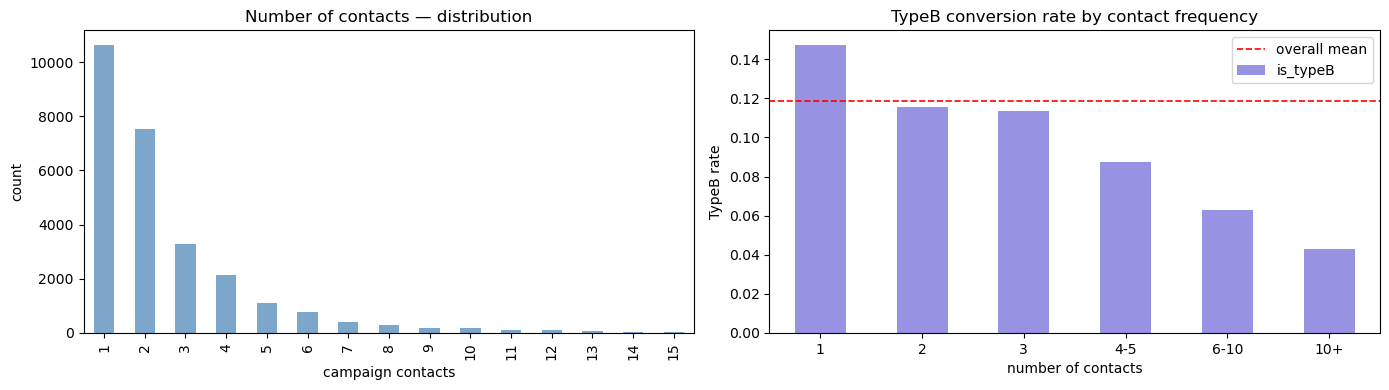

In [25]:
# ── visualise ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left — count distribution
df_ts['campaign'].value_counts().sort_index().head(15).plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.7
)
axes[0].set_title('Number of contacts — distribution')
axes[0].set_xlabel('campaign contacts')
axes[0].set_ylabel('count')

# right — conversion rate by bin
conv_by_bin = df_ts.groupby('campaign_bin')['is_typeB'].mean()
conv_by_bin.plot(kind='bar', ax=axes[1], color='#7F77DD', alpha=0.8)
axes[1].set_title('TypeB conversion rate by contact frequency')
axes[1].set_xlabel('number of contacts')
axes[1].set_ylabel('TypeB rate')
axes[1].axhline(df_ts['is_typeB'].mean(), color='red', 
                linestyle='--', linewidth=1.2, label='overall mean')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── clean up temp columns ─────────────────────────────
df_ts = df_ts.drop(columns=['campaign_bin'])

In [26]:
# ── age bins and TypeB conversion rate ────────────────
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

# define age bins
age_bins    = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels  = ['10-20', '20-30', '30-40', '40-50', 
               '50-60', '60-70', '70-80', '80-90', '90-100']

df_ts['age_bin'] = pd.cut(df_ts['age'], bins=age_bins, labels=age_labels, right=False)

# summary table
age_summary = df_ts.groupby('age_bin', observed=True).agg(
    total        = ('is_typeB', 'count'),
    converted    = ('is_typeB', 'sum'),
    conversion_rate = ('is_typeB', 'mean')
).reset_index()

age_summary['not_converted']    = age_summary['total'] - age_summary['converted']
age_summary['conversion_rate']  = (age_summary['conversion_rate'] * 100).round(2)

print(age_summary[['age_bin','total','converted','not_converted','conversion_rate']]
      .to_string(index=False))

age_bin  total  converted  not_converted  conversion_rate
  10-20     99         29             70            29.29
  20-30   5395        802           4593            14.87
  30-40   8588        912           7676            10.62
  40-50   7102        664           6438             9.35
  50-60   5028        462           4566             9.19
  60-70    725        224            501            30.90
  70-80    262        118            144            45.04
  80-90     66         24             42            36.36
 90-100      7          7              0           100.00


In [30]:
# ── campaign contact count and TypeB conversion ───────
df_ts['is_typeB'] = (df_ts['y'] == 'TypeB').astype(int)

# updated bins — single contact gets its own bin
campaign_bins   = [0, 1, 5, 10, 20, 30, 40, 50, 64]
campaign_labels = ['1', '2-5', '6-10', '11-20', '21-30', '31-40', '41-50', '51-63']

df_ts['campaign_bin'] = pd.cut(df_ts['campaign'], 
                                bins=campaign_bins, 
                                labels=campaign_labels, 
                                right=True)

# summary table
campaign_summary = df_ts.groupby('campaign_bin', observed=True).agg(
    total           = ('is_typeB', 'count'),
    converted       = ('is_typeB', 'sum'),
    conversion_rate = ('is_typeB', 'mean')
).reset_index()

campaign_summary['not_converted']   = campaign_summary['total'] - campaign_summary['converted']
campaign_summary['conversion_rate'] = (campaign_summary['conversion_rate'] * 100).round(2)

print(campaign_summary[['campaign_bin','total','converted',
                         'not_converted','conversion_rate']].to_string(index=False))



campaign_bin  total  converted  not_converted  conversion_rate
           1  10641       1569           9072            14.74
         2-5  14067       1526          12541            10.85
        6-10   1864        117           1747             6.28
       11-20    565         27            538             4.78
       21-30    107          2            105             1.87
       31-40     23          1             22             4.35
       41-50      3          0              3             0.00
       51-63      2          0              2             0.00
